<a href="https://colab.research.google.com/github/adfaihsan/TugasAkhir/blob/main/01_Preprocessing_Eksplorasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Preprocessing & Eksplorasi Dataset
**Platform**: Google Colab | **Proyek**: Tugas Akhir — Klasifikasi Tumor Otak MRI

Notebook ini berisi seluruh proses persiapan data dari awal hingga siap digunakan untuk training model.

**Tahapan:**
1. Project Setup & Mount Google Drive
2. Download Dataset dari Kaggle
3. Audit & Analisis Dataset
4. Deteksi & Pembersihan Duplikat
5. Analisis Dimensi Gambar
6. Offline Preprocessing (Resize & Normalize)
7. Visual Inspection & Quality Check
8. Visualisasi Sampel untuk Skripsi
9. Referensi Metrik Evaluasi

## 1. Project Setup & Mount Google Drive

In [ ]:
"""
=============================================================================
CELL 1: PROJECT SETUP & MOUNT GOOGLE DRIVE
=============================================================================
Menginisialisasi environment Colab, mount Google Drive, dan membuat
struktur folder proyek.
"""

import os
import json
import shutil

# ---------------------------------------------------------------------------
# 1. MOUNT GOOGLE DRIVE
# ---------------------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

# ---------------------------------------------------------------------------
# 2. DEFINISIKAN PATH UTAMA
# ---------------------------------------------------------------------------
BASE_PATH = '/content/drive/MyDrive/TugasAkhir'
DATASET_PATH = os.path.join(BASE_PATH, 'Dataset')
NOTEBOOK_PATH = os.path.join(BASE_PATH, 'Notebook')

# Path dataset mentah (sebelum preprocessing)
BRAIN_TUMOR_PATH = os.path.join(DATASET_PATH, 'brain_tumor')
TRAIN_PATH = os.path.join(BRAIN_TUMOR_PATH, 'train')
TEST_PATH = os.path.join(BRAIN_TUMOR_PATH, 'test')
VAL_PATH = os.path.join(BRAIN_TUMOR_PATH, 'val')

# Path dataset preprocessed (setelah preprocessing)
PREPROCESSED_PATH = os.path.join(DATASET_PATH, 'Preprocessing')

# ---------------------------------------------------------------------------
# 3. BUAT STRUKTUR FOLDER PROYEK
# ---------------------------------------------------------------------------
output_folders = {
    'Models': 'Menyimpan trained model (.keras)',
    'Saved_Models': 'Menyimpan model terbaik (backup)',
    'Results': 'Menyimpan hasil eksperimen (metrics, CSV)',
    'Visualizations': 'Menyimpan grafik & confusion matrix',
    'Reports': 'Menyimpan laporan analisis',
    'Checkpoints': 'Menyimpan checkpoint training',
}

print("=" * 70)
print("MENGINISIALISASI PROJECT TUGAS AKHIR")
print("=" * 70)

if not os.path.exists(DATASET_PATH):
    os.makedirs(DATASET_PATH)

for folder_name, description in output_folders.items():
    folder_path = os.path.join(BASE_PATH, folder_name)
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f"  [+] Created: {folder_name:<15} | {description}")
    else:
        print(f"  [=] Exists:  {folder_name:<15} | {description}")

# ---------------------------------------------------------------------------
# 4. SIMPAN KONFIGURASI PROJECT
# ---------------------------------------------------------------------------
config = {
    'BASE_PATH': BASE_PATH,
    'DATASET_PATH': DATASET_PATH,
    'BRAIN_TUMOR_PATH': BRAIN_TUMOR_PATH,
    'PREPROCESSED_PATH': PREPROCESSED_PATH,
    'MODELS_PATH': os.path.join(BASE_PATH, 'Models'),
    'SAVED_MODELS_PATH': os.path.join(BASE_PATH, 'Saved_Models'),
    'RESULTS_PATH': os.path.join(BASE_PATH, 'Results'),
    'VISUALIZATIONS_PATH': os.path.join(BASE_PATH, 'Visualizations'),
    'REPORTS_PATH': os.path.join(BASE_PATH, 'Reports'),
}

config_file = os.path.join(BASE_PATH, 'project_config.json')
with open(config_file, 'w') as f:
    json.dump(config, f, indent=2)

print("\n" + "=" * 70)
print("SETUP SELESAI")
print("=" * 70)
print(f"  Base Path     : {BASE_PATH}")
print(f"  Dataset Path  : {DATASET_PATH}")
print(f"  Config Saved  : {config_file}")


Mounted at /content/drive
MENGINISIALISASI PROJECT TUGAS AKHIR
  [=] Exists:  Models          | Menyimpan trained model (.keras)
  [=] Exists:  Saved_Models    | Menyimpan model terbaik (backup)
  [=] Exists:  Results         | Menyimpan hasil eksperimen (metrics, CSV)
  [=] Exists:  Visualizations  | Menyimpan grafik & confusion matrix
  [=] Exists:  Reports         | Menyimpan laporan analisis
  [=] Exists:  Checkpoints     | Menyimpan checkpoint training

SETUP SELESAI
  Base Path     : /content/drive/MyDrive/TugasAkhir
  Dataset Path  : /content/drive/MyDrive/TugasAkhir/Dataset
  Config Saved  : /content/drive/MyDrive/TugasAkhir/project_config.json


## 2. Setup Kaggle API

In [ ]:
"""
=============================================================================
CELL 2: SETUP KAGGLE API
=============================================================================
Upload kaggle.json untuk authenticate dengan Kaggle API.
"""

from google.colab import files
import json

print("Please upload your kaggle.json file...")
print("(The file you downloaded from Kaggle → Settings → API)")
print("\nClick 'Choose Files' button below:")

# Upload kaggle.json
uploaded = files.upload()

# Verify upload
if 'kaggle.json' in uploaded:
    print("\nkaggle.json uploaded successfully!")

    # Create .kaggle directory
    !mkdir -p ~/.kaggle

    # Move kaggle.json to proper location
    !cp kaggle.json ~/.kaggle/

    # Set proper permissions (important for security)
    !chmod 600 ~/.kaggle/kaggle.json

    # Verify credentials
    print("\nVerifying Kaggle credentials...")
    !kaggle datasets list --max-size 1

    print("\nKaggle API setup complete!")
else:
    print("\nkaggle.json not found. Please upload the file.")

Please upload your kaggle.json file...
(The file you downloaded from Kaggle → Settings → API)

Click 'Choose Files' button below:


Saving kaggle.json to kaggle.json

kaggle.json uploaded successfully!

Verifying Kaggle credentials...
ref                                                              title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
krishchaudhary14/indian-stock-market-full-5-year-history         Indian Stock Market: Full 5-Year History              84802521  2026-05-01 18:23:35.257000            246         23  0.88235295       
patelris/anime-and-manga-dataset-2026                            🎌 Complete Anime & Manga Dataset (2026)               25312396  2026-05-01 14:14:44.743000            584         28  1                
darkmatternet/s-and-p-500-stocks-25-years-of-data-updated-daily  S&P 500 Stocks: 25 Years of 

## 3. Download & Restructure Dataset

In [ ]:
"""
=============================================================================
CELL 3: DOWNLOAD & RESTRUCTURE DATASET (KAGGLE)
=============================================================================
1. Download Brain Tumor MRI dataset dari Kaggle.
2. Ekstrak file zip.
3. Restrukturisasi & Stratified Split (80% Train, 10% Val, 10% Test).
"""

import os
import zipfile
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split

# Configuration
KAGGLE_DATASET = 'masoudnickparvar/brain-tumor-mri-dataset'
DOWNLOAD_PATH = DATASET_PATH
TARGET_FOLDER_NAME = 'brain_tumor'
FINAL_EXTRACT_PATH = os.path.join(DOWNLOAD_PATH, TARGET_FOLDER_NAME)

print("="*70)
print("DOWNLOADING BRAIN TUMOR MRI DATASET")
print("="*70)

# Cek apakah dataset sudah ada dan struktur train/val/test sudah terbentuk
if os.path.exists(os.path.join(FINAL_EXTRACT_PATH, 'train')) and \
   os.path.exists(os.path.join(FINAL_EXTRACT_PATH, 'val')) and \
   os.path.exists(os.path.join(FINAL_EXTRACT_PATH, 'test')):
    print(f"\nDataset folder '{TARGET_FOLDER_NAME}' sudah ada dan terstruktur!")
    print("   Location:", FINAL_EXTRACT_PATH)
    print("Skipping download & split. Menggunakan dataset yang ada.")

else:
    print(f"\nDownloading dataset from Kaggle...")
    print(f"Destination: {DOWNLOAD_PATH}")

    os.chdir(DOWNLOAD_PATH)
    !kaggle datasets download -d {KAGGLE_DATASET}

    print("\nDownload complete! Preparing to extract...")
    zip_files = list(Path(DOWNLOAD_PATH).glob('*.zip'))

    if zip_files:
        zip_path = str(zip_files[0])
        print(f"Found Zip: {zip_path}")

        if not os.path.exists(FINAL_EXTRACT_PATH):
            os.makedirs(FINAL_EXTRACT_PATH)

        print(f"Extracting into: {TARGET_FOLDER_NAME}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(FINAL_EXTRACT_PATH)

        print("Extraction complete!")
        os.remove(zip_path)
        print(f"Removed zip file to save space")

        # =====================================================================
        # PROSES SAFE SPLITTING (Testing -> Val & Test)
        # =====================================================================
        print("\n" + "="*70)
        print("MEMULAI SAFE DATA SPLIT (Mencegah Data Leakage)")
        print("="*70)

        original_train = os.path.join(FINAL_EXTRACT_PATH, 'Training')
        original_test = os.path.join(FINAL_EXTRACT_PATH, 'Testing')

        new_train = os.path.join(FINAL_EXTRACT_PATH, 'train')
        new_val = os.path.join(FINAL_EXTRACT_PATH, 'val')
        new_test = os.path.join(FINAL_EXTRACT_PATH, 'test')

        classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

        # 1. Rename folder 'Training' menjadi 'train' secara utuh (5600 gambar)
        if os.path.exists(original_train):
            os.rename(original_train, new_train)
            print("Folder 'Training' berhasil diubah menjadi 'train' (Utuh).")

        # 2. Split folder 'Testing' (1600 gambar) menjadi 'val' (800) dan 'test' (800)
        if os.path.exists(original_test):
            print("Membagi folder 'Testing' menjadi 'val' dan 'test' (50/50 per kelas)...")

            for cls in classes:
                src_cls_dir = os.path.join(original_test, cls)
                val_cls_dir = os.path.join(new_val, cls)
                test_cls_dir = os.path.join(new_test, cls)

                os.makedirs(val_cls_dir, exist_ok=True)
                os.makedirs(test_cls_dir, exist_ok=True)

                # Ambil semua file di kelas tersebut
                files = [f for f in os.listdir(src_cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

                # Gunakan train_test_split untuk membagi 50/50 secara acak namun konsisten (seed 42)
                val_files, test_files = train_test_split(files, test_size=0.5, random_state=42)

                # Pindahkan file ke folder masing-masing
                for f in val_files:
                    shutil.move(os.path.join(src_cls_dir, f), os.path.join(val_cls_dir, f))
                for f in test_files:
                    shutil.move(os.path.join(src_cls_dir, f), os.path.join(test_cls_dir, f))

                print(f"   - {cls:<12}: {len(val_files)} ke 'val', {len(test_files)} ke 'test'.")

            # Hapus folder Testing asli yang sudah kosong
            shutil.rmtree(original_test)
            print("Restrukturisasi Safe Split berhasil!")

    else:
        print("No zip file found. Download may have failed.")

os.chdir('/content')

print("\n" + "="*70)
print("DOWNLOAD & RESTRUCTURING COMPLETE")
print("="*70)

DOWNLOADING BRAIN TUMOR MRI DATASET

Destination: /content/drive/MyDrive/TugasAkhir/Dataset
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:00<00:00, 169MB/s]


Download complete! Preparing to extract...
Found Zip: /content/drive/MyDrive/TugasAkhir/Dataset/brain-tumor-mri-dataset.zip
Extracting into: brain_tumor...
Extraction complete!
Removed zip file to save space

MEMULAI SAFE DATA SPLIT (Mencegah Data Leakage)
Folder 'Training' berhasil diubah menjadi 'train' (Utuh).
Membagi folder 'Testing' menjadi 'val' dan 'test' (50/50 per kelas)...
   - glioma      : 200 ke 'val', 200 ke 'test'.
   - meningioma  : 200 ke 'val', 200 ke 'test'.
   - notumor     : 200 ke 'val', 200 ke 'test'.
   - pituitary   : 200 ke 'val', 200 ke 'test'.
Restrukturisasi Safe Split berhasil!

DOWNLOAD & RESTRUCTURING COMPLETE


## 4. Comprehensive Dataset Audit & Analysis

In [ ]:
"""
=============================================================================
CELL 4: COMPREHENSIVE DATASET AUDIT & ANALYSIS
=============================================================================
Melakukan verifikasi menyeluruh terhadap dataset:
1. Visualisasi Struktur Folder (Tree View).
2. Audit Jumlah File (Train/Test/Val).
3. Analisis Distribusi Kelas & Rekomendasi Class Weights.
4. Analisis Rasio Citra Asli vs Augmentasi (Metadata Pattern).
"""

import os
import re
from pathlib import Path

# ==========================================
# FUNGSI 1: VISUALISASI STRUKTUR (TREE VIEW)
# ==========================================
def inspect_structure_tree(start_path):
    print("\n" + "="*70)
    print(f"VISUALISASI STRUKTUR FOLDER: {os.path.basename(start_path)}")
    print("="*70)

    if not os.path.exists(start_path):
        print(f"Error: Path '{start_path}' tidak ditemukan.")
        return

    for root, dirs, files in os.walk(start_path):
        level = root.replace(start_path, '').count(os.sep)
        indent = ' ' * 4 * level
        folder_name = os.path.basename(root)
        if folder_name == '': folder_name = os.path.basename(start_path)

        print(f"{indent}    {folder_name}/")

        if files:
            img_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            count = len(img_files)
            if count > 0:
                print(f"{indent}       {count} images (Sample: {img_files[:2]})")

# ==========================================
# FUNGSI 2: AUDIT JUMLAH DATA (QUANTITATIVE)
# ==========================================
def audit_dataset_stats(dataset_path):
    print("\n" + "="*70)
    print("STATISTIK DATASET (DETAILED COUNT)")
    print("="*70)

    splits = ['train', 'test', 'val']
    grand_total = 0

    for split in splits:
        split_path = os.path.join(dataset_path, split)

        print(f"\nSPLIT: {split.upper()}")
        print("-" * 40)

        if not os.path.exists(split_path):
            print(f"       Folder '{split}' tidak ditemukan!")
            continue

        available_classes = [d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))]
        available_classes.sort()

        split_total = 0

        if not available_classes:
             print("       Folder kosong (tidak ada sub-folder kelas)")

        for class_name in available_classes:
            class_path = os.path.join(split_path, class_name)
            num_files = len([f for f in Path(class_path).rglob('*')
                             if f.is_file() and f.suffix.lower() in ['.jpeg', '.jpg', '.png']])

            print(f"       {class_name:<15}: {num_files:>5} images")
            split_total += num_files

        print("-" * 40)
        print(f"       TOTAL {split.upper():<9}: {split_total:>5} images")
        grand_total += split_total

    print("\n" + "="*70)
    print(f"GRAND TOTAL DATASET: {grand_total} images")
    print("="*70)

# ==========================================
# FUNGSI 3: CLASS DISTRIBUTION & WEIGHTS
# ==========================================
def analyze_class_distribution(dataset_path):
    print("\n" + "="*70)
    print("CLASS DISTRIBUTION & BALANCE ANALYSIS")
    print("="*70)

    class_counts = {
        'glioma': 0,
        'meningioma': 0,
        'notumor': 0,
        'pituitary': 0
    }

    for root, dirs, files in os.walk(dataset_path):
        for filename in files:
            if not filename.lower().endswith(('.jpeg', '.jpg', '.png')):
                continue

            category = os.path.basename(root).lower()
            for key in class_counts.keys():
                if key in category:
                    class_counts[key] += 1
                    break

    total_images = sum(class_counts.values())

    if total_images == 0:
        print("Tidak ada gambar ditemukan untuk dianalisis.")
        return

    print("\nPROPORSI KELAS (ALL SPLITS):")
    print("-" * 50)
    print(f"   {'Kelas':<15} | {'Jumlah':<8} | {'Persentase':<10}")
    print("-" * 50)

    for cls, count in class_counts.items():
        percentage = (count / total_images) * 100
        print(f"   {cls.capitalize():<15} | {count:<8} | {percentage:>6.2f}%")

    print("-" * 50)

    print("\nREKOMENDASI CLASS WEIGHTS (Untuk Training):")
    print("-" * 50)
    num_classes = len(class_counts)

    for i, (cls, count) in enumerate(class_counts.items()):
        if count > 0:
            weight = total_images / (num_classes * count)
            print(f"   class {i} ({cls.capitalize()[:3]}.) : {weight:.4f}")
        else:
            print(f"   class {i} ({cls.capitalize()[:3]}.) : 0.0000 (Data Kosong)")

    print("-" * 50)
    print("Catatan: Jika bobot mendekati 1.0, berarti dataset sudah seimbang (Balanced).")

# ==========================================
# FUNGSI 4: METADATA & OFFLINE AUGMENTATION ANALYSIS
# ==========================================
def analyze_metadata_pattern(dataset_path):
    print("\n" + "="*70)
    print("METADATA & OFFLINE AUGMENTATION ANALYSIS")
    print("="*70)

    stats = {
        'glioma': {'asli': 0, 'aug': 0},
        'meningioma': {'asli': 0, 'aug': 0},
        'notumor': {'asli': 0, 'aug': 0},
        'pituitary': {'asli': 0, 'aug': 0}
    }

    total_images = 0

    for root, dirs, files in os.walk(dataset_path):
        for filename in files:
            if not filename.lower().endswith(('.jpeg', '.jpg', '.png')):
                continue

            category = os.path.basename(root).lower()

            matched_class = None
            for key in stats.keys():
                if key in category:
                    matched_class = key
                    break

            if matched_class:
                total_images += 1
                if 'aug' in filename.lower():
                    stats[matched_class]['aug'] += 1
                else:
                    stats[matched_class]['asli'] += 1

    if total_images == 0:
        print("Tidak ada gambar yang ditemukan.")
        return

    print("RASIO CITRA ASLI vs AUGMENTASI (Per Kelas):")
    print("-" * 65)
    print(f"   {'Kelas':<15} | {'Total':<7} | {'Asli':<10} | {'Augmented':<10}")
    print("-" * 65)

    total_asli = 0
    total_aug = 0

    for cls, count in stats.items():
        cls_total = count['asli'] + count['aug']
        total_asli += count['asli']
        total_aug += count['aug']

        pct_asli = (count['asli'] / cls_total * 100) if cls_total > 0 else 0
        pct_aug = (count['aug'] / cls_total * 100) if cls_total > 0 else 0

        print(f"   {cls.capitalize():<15} | {cls_total:<7} | {count['asli']:<4} ({pct_asli:>4.1f}%) | {count['aug']:<4} ({pct_aug:>4.1f}%)")

    print("-" * 65)

    pct_grand_asli = (total_asli / total_images) * 100
    pct_grand_aug = (total_aug / total_images) * 100

    print(f"   {'GRAND TOTAL':<15} | {total_images:<7} | {total_asli:<4} ({pct_grand_asli:>4.1f}%) | {total_aug:<4} ({pct_grand_aug:>4.1f}%)")
    print("="*70)

# ==========================================
# EKSEKUSI UTAMA
# ==========================================
try:
    target_path = BRAIN_TUMOR_PATH
    print(f"Target Analysis Path: {target_path}")

    if os.path.exists(target_path):
        inspect_structure_tree(target_path)
        audit_dataset_stats(target_path)
        analyze_class_distribution(target_path)
        analyze_metadata_pattern(target_path)
    else:
        print(f"Critical Error: Folder dataset tidak ditemukan di: {target_path}")
        print("   Pastikan Cell 3 (Download & Split) sudah dijalankan.")

except NameError:
    print("Error: BRAIN_TUMOR_PATH belum didefinisikan.")
    print("   Mohon jalankan Cell 1 (Project Setup) terlebih dahulu.")

Target Analysis Path: /content/drive/MyDrive/TugasAkhir/Dataset/brain_tumor

VISUALISASI STRUKTUR FOLDER: brain_tumor
    brain_tumor/
        train/
            glioma/
               1400 images (Sample: ['Tr-gl_1.jpg', 'Tr-gl_10.jpg'])
            meningioma/
               1400 images (Sample: ['Tr-aug-me_1.jpg', 'Tr-aug-me_10.jpg'])
            notumor/
               1400 images (Sample: ['Tr-no_1.jpg', 'Tr-no_10.jpg'])
            pituitary/
               1400 images (Sample: ['Tr-pi_1.jpg', 'Tr-pi_10.jpg'])
        val/
            glioma/
               200 images (Sample: ['Te-gl_10.jpg', 'Te-gl_100.jpg'])
            meningioma/
               200 images (Sample: ['Te-aug-me_10.jpg', 'Te-aug-me_100.jpg'])
            notumor/
               200 images (Sample: ['Te-no_10.jpg', 'Te-no_100.jpg'])
            pituitary/
               200 images (Sample: ['Te-pi_10.jpg', 'Te-pi_100.jpg'])
        test/
            glioma/
               200 images (Sample: ['Te-gl_1.jpg', 'Te-

## 5. Deteksi Duplikat

MEMULAI PEMINDAIAN DUPLIKAT (MD5 HASHING)
   ...Memindai 1000 file...
   ...Memindai 2000 file...
   ...Memindai 3000 file...
   ...Memindai 4000 file...
   ...Memindai 5000 file...
   ...Memindai 6000 file...
   ...Memindai 7000 file...
Pindai selesai. Total file dicek: 7200

PERINGATAN: DITEMUKAN 153 KELOMPOK DUPLIKAT

Hash: ef4efdf1a7... (Jumlah Copy: 2)
       STATUS: Duplikat Internal (Duplikat dalam satu split)
   1. [TRAIN/meningioma] Tr-aug-me_90.jpg
   2. [TRAIN/meningioma] Tr-me_1242.jpg

Hash: 9e7c7e8d5d... (Jumlah Copy: 2)
       STATUS: Duplikat Internal (Duplikat dalam satu split)
   1. [TRAIN/meningioma] Tr-aug-me_98.jpg
   2. [TRAIN/meningioma] Tr-me_1274.jpg

Hash: 9d8e272715... (Jumlah Copy: 2)
       STATUS: Duplikat Internal (Duplikat dalam satu split)
   1. [TRAIN/meningioma] Tr-aug-me_95.jpg
   2. [TRAIN/meningioma] Tr-me_1295.jpg

Hash: 832c3e0243... (Jumlah Copy: 2)
       STATUS: Duplikat Internal (Duplikat dalam satu split)
   1. [TRAIN/meningioma] Tr-me_1094.

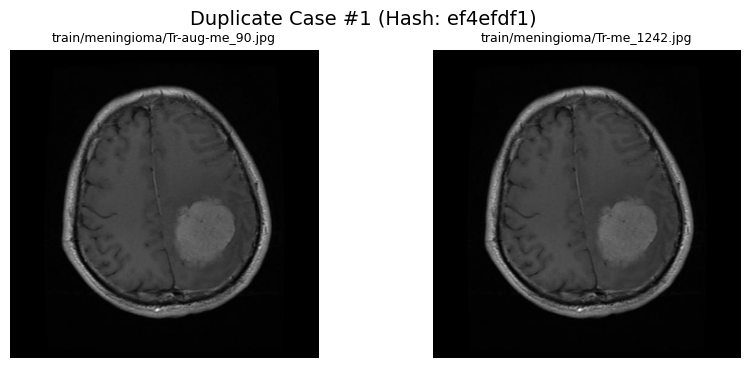

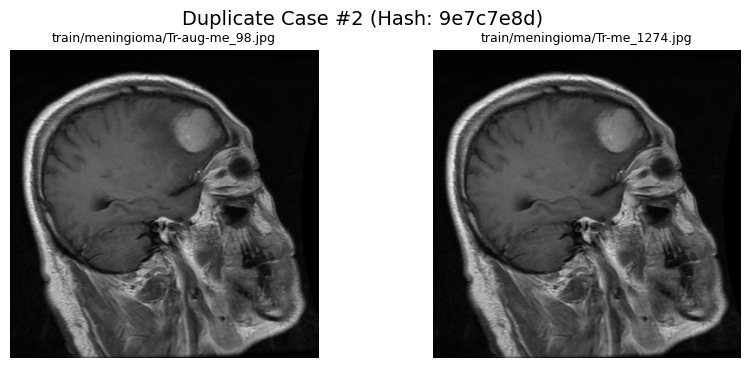

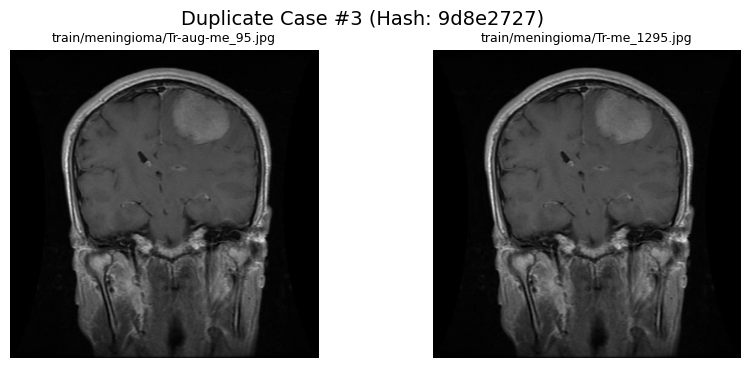

In [ ]:
"""
=============================================================================
CELL 5: DUPLICATE DETECTION & AUDIT (BRAIN TUMOR)
=============================================================================
Mendeteksi gambar duplikat menggunakan MD5 Hashing.
Fokus: Mencegah Data Leakage antara set Training, Validation, dan Testing.
"""

import os
import hashlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def get_file_hash(filepath):
    """Menghitung MD5 hash dari sebuah file."""
    with open(filepath, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

def find_duplicates(dataset_path):
    print("="*70)
    print("MEMULAI PEMINDAIAN DUPLIKAT (MD5 HASHING)")
    print("="*70)

    hashes = {}
    duplicates = {}

    # Counter untuk statistik
    total_files = 0

    # 1. Scan semua file
    for root, dirs, files in os.walk(dataset_path):
        for filename in files:
            if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            filepath = os.path.join(root, filename)
            file_hash = get_file_hash(filepath)

            # Cek apakah hash sudah ada
            if file_hash in hashes:
                # DITEMUKAN DUPLIKAT!
                if file_hash not in duplicates:
                    duplicates[file_hash] = [hashes[file_hash]] # Masukkan file pertama
                duplicates[file_hash].append(filepath) # Masukkan file kedua (duplikatnya)
            else:
                hashes[file_hash] = filepath

            total_files += 1
            if total_files % 1000 == 0:
                print(f"   ...Memindai {total_files} file...")

    print(f"Pindai selesai. Total file dicek: {total_files}")

    return duplicates

def audit_duplicates(duplicates_dict):
    """
    Menampilkan laporan dan visualisasi duplikat untuk audit manual.
    """
    if not duplicates_dict:
        print("\nSELAMAT! Tidak ditemukan duplikat sama sekali.")
        print("   Dataset Anda bersih dari duplikat persis bit-per-bit.")
        return

    print("\n" + "="*70)
    print(f"PERINGATAN: DITEMUKAN {len(duplicates_dict)} KELOMPOK DUPLIKAT")
    print("="*70)

    leakage_count = 0
    internal_dup_count = 0

    # 2. Analisis Jenis Duplikat
    for file_hash, file_list in duplicates_dict.items():
        # Cek apakah duplikat lintas folder (Train vs Test vs Val)
        folders = [path.split('/')[-3] for path in file_list] # Ambil nama folder (train/test/val)
        unique_folders = set(folders)

        print(f"\nHash: {file_hash[:10]}... (Jumlah Copy: {len(file_list)})")

        is_leakage = len(unique_folders) > 1
        if is_leakage:
            print("       STATUS: DATA LEAKAGE! (Duplikat tersebar di split berbeda)")
            leakage_count += 1
        else:
            print("       STATUS: Duplikat Internal (Duplikat dalam satu split)")
            internal_dup_count += 1

        for i, path in enumerate(file_list):
            # Highlight folder train/test/val agar mata mudah melihat
            split_name = path.split('/')[-3].upper()
            cls_name = path.split('/')[-2]
            fname = os.path.basename(path)
            print(f"   {i+1}. [{split_name}/{cls_name}] {fname}")

    print("\n" + "="*70)
    print("RINGKASAN MASALAH")
    print("-" * 40)
    print(f"   Total Kasus Duplikat : {len(duplicates_dict)}")
    print(f"       Bahaya (Leakage)  : {leakage_count} kasus")
    print(f"       Aman (Internal)   : {internal_dup_count} kasus")
    print("="*70)

    # 3. Visualisasi (Audit Manual)
    # Tampilkan maksimal 3 kasus pertama untuk diperiksa mata manusia
    print("\nVISUAL AUDIT (Menampilkan 3 Kasus Pertama)")

    count = 0
    for file_hash, file_list in duplicates_dict.items():
        if count >= 3: break

        plt.figure(figsize=(10, 4))
        plt.suptitle(f"Duplicate Case #{count+1} (Hash: {file_hash[:8]})", fontsize=14)

        # Tampilkan max 2 gambar per kasus (original & duplikatnya)
        for i in range(min(2, len(file_list))):
            img_path = file_list[i]
            img = mpimg.imread(img_path)

            plt.subplot(1, 2, i+1)
            plt.imshow(img, cmap='gray')

            # Ambil info path pendek untuk judul
            short_path = "/".join(img_path.split('/')[-3:])
            plt.title(short_path, fontsize=9)
            plt.axis('off')

        plt.show()
        count += 1

# --- EKSEKUSI ---
try:
    # Menggunakan BRAIN_TUMOR_PATH
    dupes = find_duplicates(BRAIN_TUMOR_PATH)
    audit_duplicates(dupes)
except NameError:
    print("Error: BRAIN_TUMOR_PATH belum didefinisikan. Pastikan Cell 1 sudah dijalankan.")

## 6. Pembersihan Duplikat

In [ ]:
"""
=============================================================================
CELL 6-A: SMART DUPLICATE CLEANING
=============================================================================
Menghapus file duplikat untuk menjaga integritas statistik dataset.
Logika Prioritas (Jika terjadi Data Leakage):
1. Pertahankan gambar di folder 'test' (Paling penting untuk evaluasi murni).
2. Jika tidak ada di 'test', pertahankan di 'val'.
3. Jika hanya internal, pertahankan salah satu (bebas).
"""

import os

def remove_duplicates_smart(duplicates_dict):
    print("="*70)
    print("🧹 MEMBERSIHKAN DUPLIKAT (SMART DELETION)")
    print("="*70)

    if not duplicates_dict:
        print("Tidak ada duplikat untuk dihapus.")
        return

    deleted_count = 0
    kept_count = 0
    resolved_leakage = 0

    for file_hash, file_list in duplicates_dict.items():
        # Tentukan prioritas file mana yang akan dipertahankan
        # Urutan prioritas: test > val > train
        file_to_keep = None

        # Cari di test dulu
        for path in file_list:
            if '/test/' in path.lower():
                file_to_keep = path
                break

        # Kalau tidak ada di test, cari di val
        if not file_to_keep:
            for path in file_list:
                if '/val/' in path.lower():
                    file_to_keep = path
                    break

        # Kalau tidak ada di test/val (berarti internal di train), ambil yang pertama
        if not file_to_keep:
            file_to_keep = file_list[0]

        # Pisahkan mana yang disimpan dan mana yang dihapus
        files_to_remove = [p for p in file_list if p != file_to_keep]

        # Info
        folders = [p.split('/')[-3] for p in file_list]
        is_leakage = len(set(folders)) > 1

        if is_leakage:
            print(f"\nResolving LEAKAGE (Hash: {file_hash[:8]}...)")
            resolved_leakage += 1
        else:
            print(f"\nResolving Internal (Hash: {file_hash[:8]}...)")

        print(f"     KEEP   : [{file_to_keep.split('/')[-3]}] {os.path.basename(file_to_keep)}")

        for file_path in files_to_remove:
            try:
                os.remove(file_path)
                print(f"     DELETE : [{file_path.split('/')[-3]}] {os.path.basename(file_path)}")
                deleted_count += 1
            except OSError as e:
                print(f"     ERROR  : Gagal menghapus {os.path.basename(file_path)} - {e}")

        kept_count += 1

    print("\n" + "="*70)
    print("LAPORAN PEMBERSIHAN")
    print("-" * 40)
    print(f"   Kelompok Duplikat   : {len(duplicates_dict)}")
    print(f"   Kebocoran Ditutup   : {resolved_leakage} kasus")
    print(f"   File Disimpan       : {kept_count}")
    print(f"   File Sampah Dihapus : {deleted_count}")
    print("="*70)
    print("Dataset sekarang 100% bersih dari Data Leakage dan Duplikat!")

# --- EKSEKUSI ---
# Pastikan variabel 'dupes' masih ada di memori dari eksekusi Cell 5.
try:
    if 'dupes' in locals() and dupes:
        remove_duplicates_smart(dupes)
    else:
        print("Variabel 'dupes' kosong atau tidak ditemukan.")
        print("   Silakan jalankan CELL 5 terlebih dahulu untuk memindai ulang.")
except NameError:
    print("Error: Silakan jalankan CELL 5 dulu.")

🧹 MEMBERSIHKAN DUPLIKAT (SMART DELETION)

Resolving Internal (Hash: ef4efdf1...)
     KEEP   : [train] Tr-aug-me_90.jpg
     DELETE : [train] Tr-me_1242.jpg

Resolving Internal (Hash: 9e7c7e8d...)
     KEEP   : [train] Tr-aug-me_98.jpg
     DELETE : [train] Tr-me_1274.jpg

Resolving Internal (Hash: 9d8e2727...)
     KEEP   : [train] Tr-aug-me_95.jpg
     DELETE : [train] Tr-me_1295.jpg

Resolving Internal (Hash: 832c3e02...)
     KEEP   : [train] Tr-me_1094.jpg
     DELETE : [train] Tr-me_219.jpg

Resolving Internal (Hash: 5ac635ab...)
     KEEP   : [train] Tr-aug-me_91.jpg
     DELETE : [train] Tr-me_245.jpg

Resolving Internal (Hash: 9120f19e...)
     KEEP   : [train] Tr-aug-me_92.jpg
     DELETE : [train] Tr-me_268.jpg

Resolving Internal (Hash: ceb4361f...)
     KEEP   : [train] Tr-aug-me_97.jpg
     DELETE : [train] Tr-me_532.jpg

Resolving Internal (Hash: af3a4cf5...)
     KEEP   : [train] Tr-me_339.jpg
     DELETE : [train] Tr-me_534.jpg
     DELETE : [train] Tr-me_86.jpg

Resol

In [ ]:
"""
=============================================================================
CELL 6-B: POST-CLEANING DATASET AUDIT
=============================================================================
Menghitung ulang jumlah file pada setiap split (Train/Val/Test) dan kelas
setelah proses penghapusan duplikat (Smart Deletion) selesai.
"""

import os
from pathlib import Path

def audit_cleaned_dataset(dataset_path):
    print("="*70)
    print("STATISTIK DATASET (PASCA-PEMBERSIHAN DUPLIKAT)")
    print("="*70)

    splits = ['train', 'val', 'test']
    grand_total = 0

    for split in splits:
        split_path = os.path.join(dataset_path, split)

        if not os.path.exists(split_path):
            print(f"\nFolder '{split}' tidak ditemukan di {dataset_path}")
            continue

        print(f"\nSPLIT: {split.upper()}")
        print("-" * 40)

        # Cari sub-folder kelas
        available_classes = [d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))]
        available_classes.sort()

        split_total = 0

        for class_name in available_classes:
            class_path = os.path.join(split_path, class_name)

            # Hitung file gambar yang tersisa
            num_files = len([f for f in Path(class_path).rglob('*')
                             if f.is_file() and f.suffix.lower() in ['.jpeg', '.jpg', '.png']])

            print(f"       {class_name:<15}: {num_files:>5} images")
            split_total += num_files

        print("-" * 40)
        print(f"       TOTAL {split.upper():<9}: {split_total:>5} images")
        grand_total += split_total

    print("\n" + "="*70)
    print(f"GRAND TOTAL DATASET SEKARANG: {grand_total} images")
    print("="*70)

# --- EKSEKUSI ---
try:
    # Menggunakan BRAIN_TUMOR_PATH (Dataset mentah tempat pembersihan dilakukan)
    # Jika variabel ini terhapus dari memori, ganti dengan string path manual Anda:
    # audit_cleaned_dataset('/content/drive/MyDrive/TugasAkhir/Dataset/brain_tumor')

    audit_cleaned_dataset(BRAIN_TUMOR_PATH)

except NameError:
    print("Error: Variabel BRAIN_TUMOR_PATH belum didefinisikan.")
    print("   Silakan jalankan Cell 1 kembali, atau gunakan path manual.")

STATISTIK DATASET (PASCA-PEMBERSIHAN DUPLIKAT)

SPLIT: TRAIN
----------------------------------------
       glioma         :  1400 images
       meningioma     :  1386 images
       notumor        :  1281 images
       pituitary      :  1362 images
----------------------------------------
       TOTAL TRAIN    :  5429 images

SPLIT: VAL
----------------------------------------
       glioma         :   191 images
       meningioma     :   198 images
       notumor        :   200 images
       pituitary      :   200 images
----------------------------------------
       TOTAL VAL      :   789 images

SPLIT: TEST
----------------------------------------
       glioma         :   195 images
       meningioma     :   200 images
       notumor        :   200 images
       pituitary      :   200 images
----------------------------------------
       TOTAL TEST     :   795 images

GRAND TOTAL DATASET SEKARANG: 7013 images


## 7. Analisis Dimensi Gambar

MENGANALISIS DIMENSI GAMBAR (WIDTH x HEIGHT)
   Sedang memindai 5429 gambar di folder TRAIN...


Scanning Dimensions:   0%|          | 0/5429 [00:00<?, ?img/s]


STATISTIK DIMENSI:
----------------------------------------
         Width   Height
count  5429.00  5429.00
mean    458.79   462.22
std     124.23   118.66
min     150.00   168.00
25%     512.00   512.00
50%     512.00   512.00
75%     512.00   512.00
max    1375.00  1446.00
----------------------------------------
   Gambar Terkecil : 150 x 168
   Gambar Terbesar : 1375 x 1446


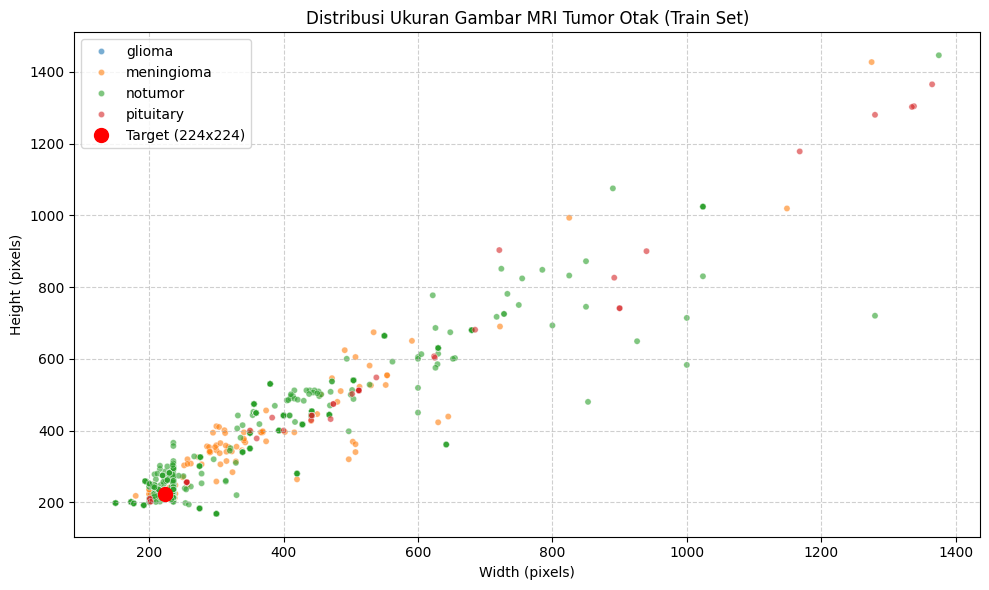

In [ ]:
"""
=============================================================================
CELL 7: IMAGE DIMENSION ANALYSIS (BRAIN TUMOR MRI)
=============================================================================
Menganalisis distribusi dimensi (Width x Height) dari dataset.
Membantu memvisualisasikan variasi ukuran asli citra MRI sebelum di-resize
ke target 224x224 untuk model DenseNet201 dan ResNet-50.
"""

import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image
from tqdm.notebook import tqdm

def analyze_dimensions(dataset_path):
    print("="*70)
    print("MENGANALISIS DIMENSI GAMBAR (WIDTH x HEIGHT)")
    print("="*70)

    dims = []

    # Loop melalui semua file
    # Kita hanya sampling TRAIN set karena itu yang mewakili mayoritas data
    train_path = os.path.join(dataset_path, 'train')

    if not os.path.exists(train_path):
        print(f"Error: Folder {train_path} tidak ditemukan.")
        return None

    total_files = sum([len(files) for r, d, files in os.walk(train_path)])

    print(f"   Sedang memindai {total_files} gambar di folder TRAIN...")

    # Progress bar untuk memantau proses scanning
    with tqdm(total=total_files, desc="Scanning Dimensions", unit="img") as pbar:
        for root, dirs, files in os.walk(train_path):
            for file in files:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    filepath = os.path.join(root, file)
                    try:
                        with Image.open(filepath) as img:
                            width, height = img.size
                            # Simpan data: [Width, Height, Class]
                            # Label akan mengambil nama folder (glioma, meningioma, notumor, pituitary)
                            label = os.path.basename(root)
                            dims.append([width, height, label])
                    except Exception as e:
                        pass
                    finally:
                        pbar.update(1)

    # Buat DataFrame
    df_dims = pd.DataFrame(dims, columns=['Width', 'Height', 'Label'])

    # Statistik Deskriptif
    print("\nSTATISTIK DIMENSI:")
    print("-" * 40)
    print(df_dims[['Width', 'Height']].describe().round(2))

    print("-" * 40)
    print(f"   Gambar Terkecil : {df_dims['Width'].min()} x {df_dims['Height'].min()}")
    print(f"   Gambar Terbesar : {df_dims['Width'].max()} x {df_dims['Height'].max()}")

    # Visualisasi Scatter Plot
    plt.figure(figsize=(10, 6))
    # Alpha dibuat 0.6 agar titik yang bertumpuk tetap terlihat jelas
    sns.scatterplot(data=df_dims, x='Width', y='Height', hue='Label', alpha=0.6, s=20)
    plt.title('Distribusi Ukuran Gambar MRI Tumor Otak (Train Set)')
    plt.xlabel('Width (pixels)')
    plt.ylabel('Height (pixels)')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Gambar titik target 224x224 sebagai referensi resizing model kita
    plt.plot(224, 224, 'ro', markersize=10, label='Target (224x224)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return df_dims

# --- EKSEKUSI ---
try:
    # Menggunakan BRAIN_TUMOR_PATH sesuai inisialisasi awal
    df_dimensions = analyze_dimensions(BRAIN_TUMOR_PATH)
except NameError:
    print("Error: BRAIN_TUMOR_PATH belum didefinisikan. Pastikan Cell 1 dijalankan.")

## 8. Offline Preprocessing (Resize & Normalize)

In [ ]:
"""
=============================================================================
CELL 8: OFFLINE PREPROCESSING
=============================================================================
Melakukan preprocessing fisik dan menyimpannya ke Drive.
Strategi:
1. Grayscale -> RGB (Kompatibilitas Model).
2. Resize 224x224 Squishing (Tanpa Padding - Menjaga detail tekstur).
3. Interpolasi Lanczos (Sharpness Preservation).
4. Tanpa CLAHE (Raw intensity untuk menjaga natural data distribution).

Optimalisasi:
Menggunakan Local Workflow (Copy-Process-Move) untuk mencegah
I/O Bottleneck / Stuck pada Google Drive.
"""

import os
import shutil
import json
import time
from PIL import Image
from tqdm.notebook import tqdm

# --- KONFIGURASI FINAL ---
TARGET_SIZE = (224, 224)
INTERPOLATION = Image.LANCZOS
OUTPUT_FOLDER_NAME = 'Preprocessing'

# Path Definisi
# Pastikan DATASET_PATH dan BRAIN_TUMOR_PATH sudah ada dari Cell 1
DRIVE_DEST_PATH = os.path.join(DATASET_PATH, OUTPUT_FOLDER_NAME)

# Path Sementara di Local Colab (Tempat Kerja)
LOCAL_SOURCE = '/content/temp_raw_dataset'
LOCAL_OUTPUT = '/content/temp_processed_dataset'

def run_turbo_preprocessing(drive_source, drive_dest):
    print("="*70)
    print("MEMULAI PREPROCESSING FINAL (TURBO MODE)")
    print("="*70)
    print(f"   Settings    : Resize {TARGET_SIZE} (Squish) | RGB | Lanczos")
    print(f"   Note        : CLAHE Disabled (Raw Intensity)")
    print("-" * 70)

    # ---------------------------------------------------------
    # LANGKAH 1: COPY DARI DRIVE KE LOCAL (Mengatasi I/O Lag)
    # ---------------------------------------------------------
    print(f"\nMenyalin data mentah dari Drive ke Local Colab...")
    print("    (Mohon tunggu, proses ini butuh waktu beberapa saat)")

    if os.path.exists(LOCAL_SOURCE):
        shutil.rmtree(LOCAL_SOURCE)

    os.makedirs(LOCAL_SOURCE, exist_ok=True)
    start_time = time.time()
    os.system(f"cp -r '{drive_source}/.' '{LOCAL_SOURCE}/'")
    print(f"      Copy selesai dalam {time.time()-start_time:.1f} detik.")

    # ---------------------------------------------------------
    # LANGKAH 2: PREPROCESSING DI LOCAL (Super Cepat)
    # ---------------------------------------------------------
    print(f"\nMemproses Gambar di Local Storage...")

    if os.path.exists(LOCAL_OUTPUT):
        shutil.rmtree(LOCAL_OUTPUT)

    total_files = sum([len(files) for r, d, files in os.walk(LOCAL_SOURCE)
                       if any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in files)])

    processed_count = 0
    errors = []

    with tqdm(total=total_files, desc="Processing (Local)", unit="img") as pbar:
        for root, dirs, files in os.walk(LOCAL_SOURCE):
            # Mirror struktur folder (train/test/val)
            rel_path = os.path.relpath(root, LOCAL_SOURCE)
            dest_dir = os.path.join(LOCAL_OUTPUT, rel_path)

            if not os.path.exists(dest_dir):
                os.makedirs(dest_dir)

            for file in files:
                if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    src_path = os.path.join(root, file)
                    dst_path = os.path.join(dest_dir, file)

                    try:
                        with Image.open(src_path) as img:
                            # A. Convert to RGB
                            if img.mode != 'RGB':
                                img = img.convert('RGB')

                            # B. Resize Squishing
                            img_resized = img.resize(TARGET_SIZE, resample=INTERPOLATION)

                            # C. Save Image ke Local
                            img_resized.save(dst_path, quality=95, optimize=True)

                            processed_count += 1
                            pbar.update(1)

                    except Exception as e:
                        errors.append(f"{file}: {str(e)}")

    # ---------------------------------------------------------
    # LANGKAH 3: PINDAHKAN HASIL KE DRIVE
    # ---------------------------------------------------------
    print(f"\nMengupload hasil jadi ke Google Drive...")
    print(f"    Target: {drive_dest}")

    if os.path.exists(drive_dest):
        print("    Menghapus folder preprocessing lama di Drive...")
        shutil.rmtree(drive_dest)

    print("    Sedang menyalin... (Jangan stop cell ini)")
    shutil.copytree(LOCAL_OUTPUT, drive_dest)

    print("\n" + "="*70)
    print("PREPROCESSING SELESAI & TERSIMPAN")
    print("-" * 40)
    print(f"   Total Berhasil  : {processed_count}")
    print(f"   Total Error     : {len(errors)}")
    print(f"   Lokasi Akhir    : {drive_dest}")

    # Bersihkan file sementara di Colab
    shutil.rmtree(LOCAL_SOURCE)
    shutil.rmtree(LOCAL_OUTPUT)
    print("File sementara di Colab telah dibersihkan.")

    return drive_dest

# --- EKSEKUSI ---
try:
    final_output_path = run_turbo_preprocessing(BRAIN_TUMOR_PATH, DRIVE_DEST_PATH)

    # Update Config File
    config_file = os.path.join(BASE_PATH, 'project_config.json')
    if os.path.exists(config_file):
        with open(config_file, 'r') as f:
            config = json.load(f)

        config['PREPROCESSED_PATH'] = final_output_path

        with open(config_file, 'w') as f:
            json.dump(config, f, indent=2)
        print(f"\nConfig updated: PREPROCESSED_PATH saved to project_config.json")

except NameError:
    print("Error: BRAIN_TUMOR_PATH belum didefinisikan. Jalankan Cell 1 terlebih dahulu.")
except Exception as e:
    print(f"\nTerjadi Error: {e}")

MEMULAI PREPROCESSING FINAL (TURBO MODE)
   Settings    : Resize (224, 224) (Squish) | RGB | Lanczos
   Note        : CLAHE Disabled (Raw Intensity)
----------------------------------------------------------------------

Menyalin data mentah dari Drive ke Local Colab...
    (Mohon tunggu, proses ini butuh waktu beberapa saat)
      Copy selesai dalam 28.9 detik.

Memproses Gambar di Local Storage...


Processing (Local):   0%|          | 0/7013 [00:00<?, ?img/s]


Mengupload hasil jadi ke Google Drive...
    Target: /content/drive/MyDrive/TugasAkhir/Dataset/Preprocessing
    Sedang menyalin... (Jangan stop cell ini)

PREPROCESSING SELESAI & TERSIMPAN
----------------------------------------
   Total Berhasil  : 7013
   Total Error     : 0
   Lokasi Akhir    : /content/drive/MyDrive/TugasAkhir/Dataset/Preprocessing
File sementara di Colab telah dibersihkan.

Config updated: PREPROCESSED_PATH saved to project_config.json


## 9. Visual Inspection & Quality Check

INSPEKSI FINAL PIPELINE: ASLI -> RESIZE (SQUISH) -> AUGMENTED
Mengambil sampel acak dari kelas: GLIOMA


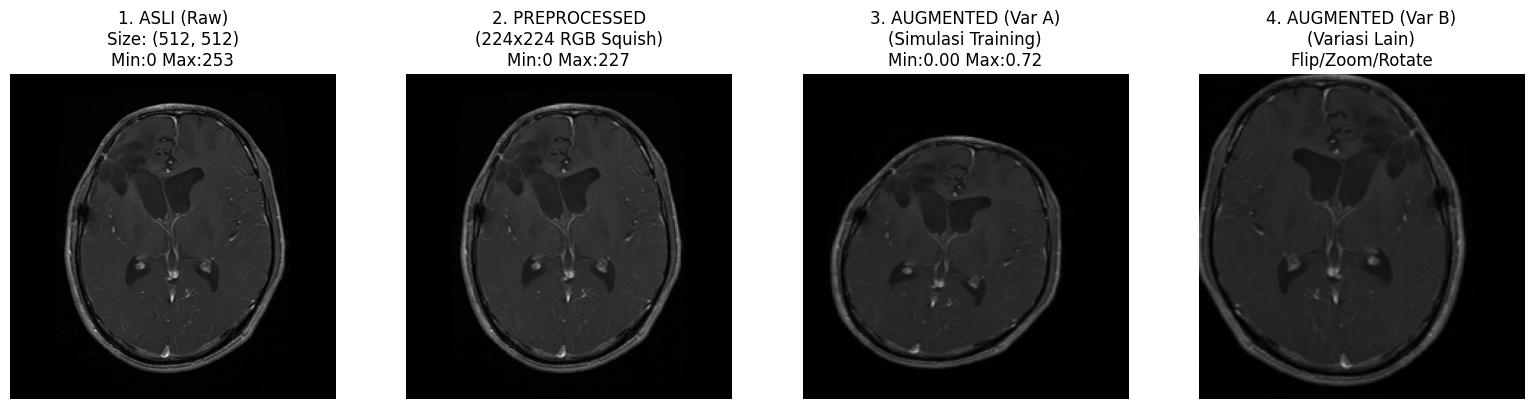

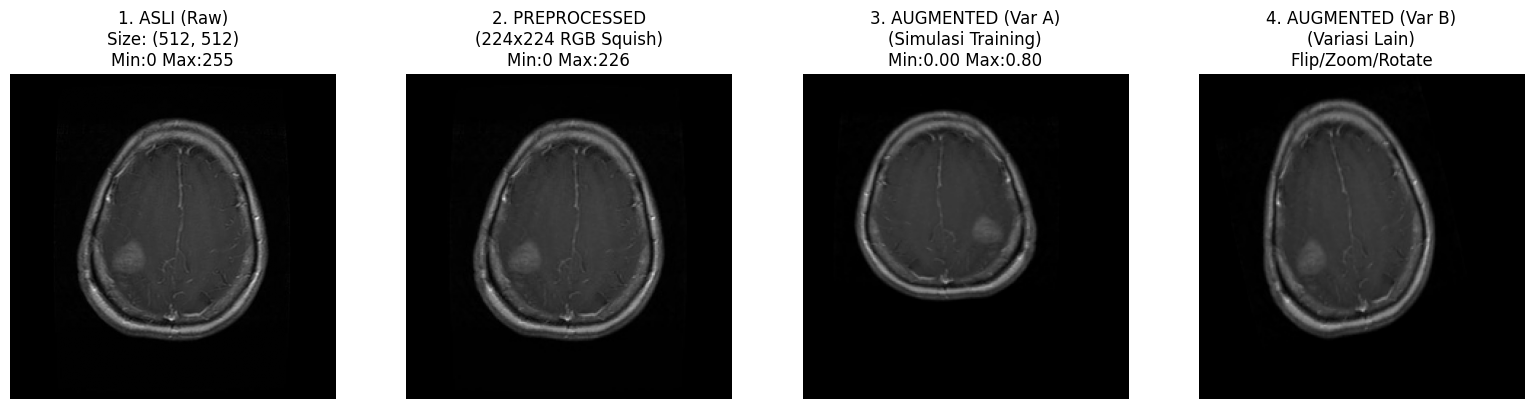

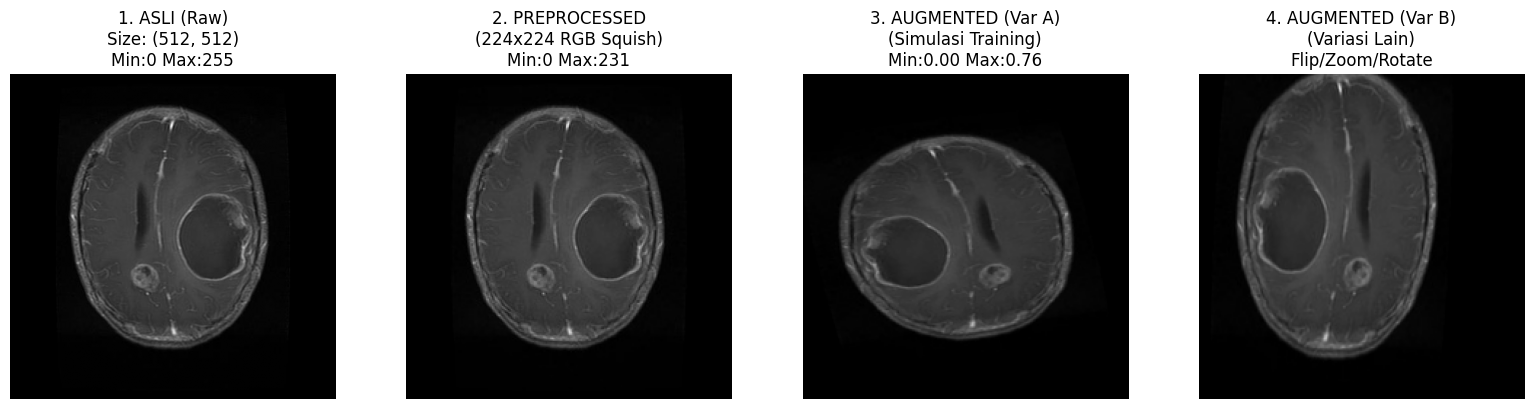

In [ ]:
"""
=============================================================================
CELL 9: VISUAL INSPECTION (BRAIN TUMOR MRI)
=============================================================================
Tujuan: Memastikan alur data benar sebelum masuk ke Training.
Membandingkan:
1. Asli (Raw Dimension).
2. Preprocessed (224x224, Squished, RGB).
3. Augmented (Simulasi Training: Rotasi ringan, Shift, Zoom, Flip).
"""

import os
import random
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array

# Pastikan path mengarah ke folder output Cell 8
try:
    TARGET_DIR = PREPROCESSED_PATH
except NameError:
    TARGET_DIR = os.path.join(DATASET_PATH, 'Preprocessing')

# --- KONFIGURASI AUGMENTASI (Disesuaikan untuk MRI) ---
# Menggunakan parameter yang lebih aman untuk mencegah distorsi ekstrem
# pada data Meningioma yang sudah di-augmentasi offline.
augmenter = ImageDataGenerator(
    rescale=1./255,             # Normalisasi On-The-Fly (Wajib)
    rotation_range=15,          # Rotasi +/- 15 derajat
    width_shift_range=0.1,      # Geser horizontal +/- 10%
    height_shift_range=0.1,     # Geser vertikal +/- 10%
    zoom_range=[0.8, 1.2],      # Zoom 80-120%
    brightness_range=[0.8, 1.2],# Brightness 80-120%
    horizontal_flip=True,       # Flip Horizontal dipertahankan untuk variasi tekstur
    fill_mode='constant',       # Isi area kosong dengan hitam
    cval=0
)

def inspect_final_pipeline(src_root, dst_root, num_samples=3):
    print("="*80)
    print("INSPEKSI FINAL PIPELINE: ASLI -> RESIZE (SQUISH) -> AUGMENTED")
    print("="*80)

    # 1. LOGIKA PENCARIAN FOLDER OTOMATIS
    train_path = os.path.join(src_root, 'train')
    if not os.path.exists(train_path):
        print(f"Error: Folder train tidak ditemukan di {train_path}")
        return

    # Ambil folder kelas
    available_classes = [d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))]

    if not available_classes:
        print("Error: Tidak ada subfolder kelas di dalam train.")
        return

    # Prioritaskan kelas tumor (misal: glioma atau meningioma)
    target_class = next((c for c in available_classes if 'glioma' in c.lower() or 'meningioma' in c.lower()), available_classes[0])

    search_path = os.path.join(train_path, target_class)
    print(f"Mengambil sampel acak dari kelas: {target_class.upper()}")

    # 2. CARI FILE (Support .jpeg/.jpg/.png)
    all_images = [os.path.join(search_path, f) for f in os.listdir(search_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if not all_images:
        print(f"Tidak ditemukan gambar di {search_path}")
        return

    # Ambil sampel acak
    samples = random.sample(all_images, min(num_samples, len(all_images)))

    for i, src_path in enumerate(samples):
        # Cari pasangan di folder Preprocessing
        rel_path = os.path.relpath(src_path, src_root)
        dst_path = os.path.join(dst_root, rel_path)

        if not os.path.exists(dst_path):
            print(f"Warning: File Preprocessing belum ada untuk: {os.path.basename(src_path)}")
            continue

        try:
            # A. Load Original
            img_orig = Image.open(src_path)

            # B. Load Preprocessed (Hasil Output Cell 8)
            img_prep = Image.open(dst_path)

            # C. Simulasi Augmentasi (On-The-Fly)
            x = img_to_array(img_prep)
            x = x.reshape((1,) + x.shape) # Reshape ke (1, 224, 224, 3)

            # Generate 2 variasi augmentasi berbeda untuk melihat efek random
            aug_iter = augmenter.flow(x, batch_size=1)
            img_aug_1 = next(aug_iter)[0] # Gambar Augmentasi 1
            img_aug_2 = next(aug_iter)[0] # Gambar Augmentasi 2

            # --- PLOTTING ---
            plt.figure(figsize=(16, 4))

            # Plot 1: Asli
            plt.subplot(1, 4, 1)
            plt.imshow(img_orig, cmap='gray')
            plt.title(f"1. ASLI (Raw)\nSize: {img_orig.size}\nMin:{np.min(img_orig):.0f} Max:{np.max(img_orig):.0f}")
            plt.axis('off')

            # Plot 2: Preprocessed (Base Input)
            plt.subplot(1, 4, 2)
            plt.imshow(img_prep)
            plt.title(f"2. PREPROCESSED\n(224x224 RGB Squish)\nMin:{np.min(img_prep):.0f} Max:{np.max(img_prep):.0f}")
            plt.axis('off')

            # Plot 3: Augmented A
            plt.subplot(1, 4, 3)
            plt.imshow(img_aug_1)
            # Cek nilai pixel (Harus 0.0 - 1.0 karena ada rescale)
            plt.title(f"3. AUGMENTED (Var A)\n(Simulasi Training)\nMin:{np.min(img_aug_1):.2f} Max:{np.max(img_aug_1):.2f}")
            plt.axis('off')

            # Plot 4: Augmented B
            plt.subplot(1, 4, 4)
            plt.imshow(img_aug_2)
            plt.title(f"4. AUGMENTED (Var B)\n(Variasi Lain)\nFlip/Zoom/Rotate")
            plt.axis('off')

            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"Error processing {os.path.basename(src_path)}: {e}")

# --- EKSEKUSI ---
try:
    if os.path.exists(TARGET_DIR):
        inspect_final_pipeline(BRAIN_TUMOR_PATH, TARGET_DIR)
    else:
        print(f"Error: Folder {TARGET_DIR} tidak ditemukan. Jalankan Cell 8 dulu.")
except NameError:
    print("Error: BRAIN_TUMOR_PATH belum didefinisikan.")

## 10. Visualisasi Sampel Dataset (Format Vertikal)

MEMBUAT VISUALISASI VERTIKAL (TEKS DI ATAS)
Visualisasi berhasil dibuat. Silakan klik kanan gambar untuk 'Save image as...'


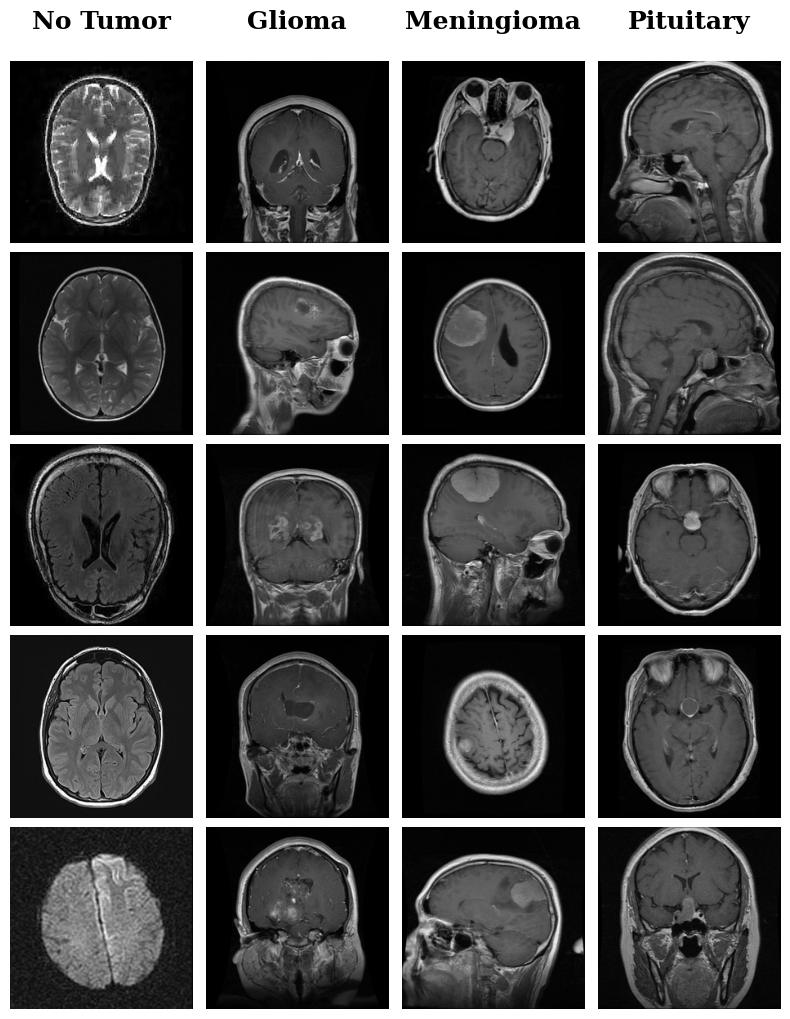

In [ ]:
"""
=============================================================================
CELL 10: VISUALISASI 5 SAMPEL PER KELAS (FORMAT VERTIKAL - TEKS DI ATAS)
=============================================================================
Menampilkan matriks 5 baris x 4 kolom gambar acak dari dataset.
Setiap kolom mewakili 1 kelas, dengan nama kelas sebagai judul di atas.
"""

import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Path dataset Preprocessing
source_path = '/content/drive/MyDrive/TugasAkhir/Dataset/Preprocessing/train'

def plot_vertical_thesis_samples_top(dataset_path, samples_per_class=5):
    print("="*70)
    print(f"MEMBUAT VISUALISASI VERTIKAL (TEKS DI ATAS)")
    print("="*70)

    # Urutan kelas (Kiri ke Kanan)
    classes = ['notumor', 'glioma', 'meningioma', 'pituitary']
    display_names = ['No Tumor', 'Glioma', 'Meningioma', 'Pituitary']

    # Kunci seed agar gambar yang terpilih permanen
    random.seed(42)

    # Buat figure matriks (5 Baris, 4 Kolom)
    fig, axes = plt.subplots(nrows=samples_per_class, ncols=len(classes), figsize=(10, 12))
    fig.patch.set_facecolor('white')

    # Looping Kolom terlebih dahulu (Setiap Kolom = 1 Kelas)
    for col, cls in enumerate(classes):
        cls_path = os.path.join(dataset_path, cls)

        if not os.path.exists(cls_path):
            print(f"Error: Folder {cls_path} tidak ditemukan.")
            return

        images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        sampled_images = random.sample(images, min(samples_per_class, len(images)))

        # Looping Baris (Menempatkan 5 gambar ke bawah)
        for row in range(samples_per_class):
            ax = axes[row, col]

            if row < len(sampled_images):
                img_path = os.path.join(cls_path, sampled_images[row])
                img = Image.open(img_path).convert('L') # Convert ke Grayscale

                ax.imshow(img, cmap='gray')

            # Hilangkan border dan garis sumbu
            ax.axis('off')

            # PERUBAHAN: Tambahkan nama kelas HANYA pada baris PERTAMA (row == 0)
            if row == 0:
                # y=1.15 berarti posisi teks berada di atas gambar pertama
                # va='bottom' agar dasar teks bertumpu pada titik koordinat
                ax.text(0.5, 1.15, display_names[col],
                        transform=ax.transAxes,
                        fontsize=18,
                        ha='center',
                        va='bottom',
                        family='serif',
                        fontweight='bold')

    # PERUBAHAN: Atur jarak top=0.9 untuk memberi ruang kosong di atas judul
    plt.subplots_adjust(wspace=0.05, hspace=0.05, top=0.9)

    print("Visualisasi berhasil dibuat. Silakan klik kanan gambar untuk 'Save image as...'")
    plt.show()

# --- EKSEKUSI ---
plot_vertical_thesis_samples_top(source_path, samples_per_class=5)

## 11. Visualisasi Sampel Dataset (Format Presentasi 2x2)

MEMBUAT VISUALISASI SAMPEL PRESENTASI (GRID 2x2)
Visualisasi 2x2 berhasil dibuat. Silakan 'Save image as...' untuk slide Anda.


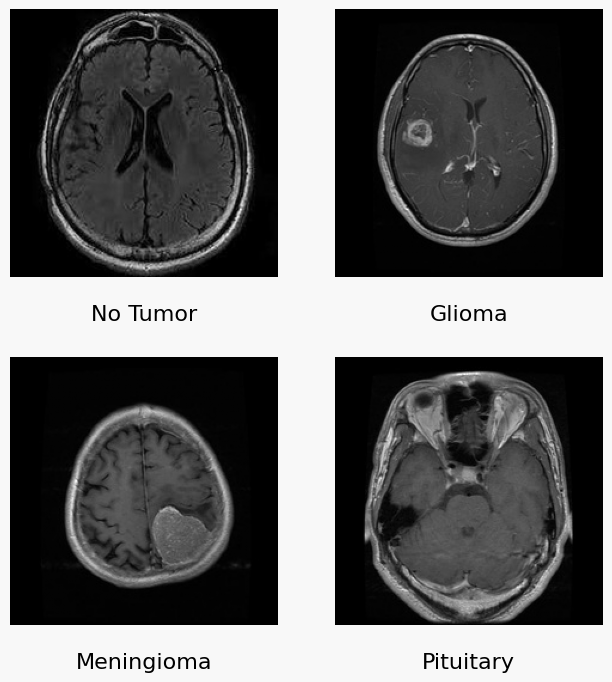

In [ ]:
"""
=============================================================================
CELL 11: VISUALISASI SAMPEL KELAS DATASET (FORMAT SLIDE PRESENTASI 2x2)
=============================================================================
Menampilkan 4 gambar pilihan dalam matriks 2x2.
Format disesuaikan untuk layar presentasi: font sans-serif, teks di bawah,
tanpa axis, dan proporsi kotak.
"""

import os
import matplotlib.pyplot as plt
from PIL import Image

# Path dataset Preprocessing
source_path = '/content/drive/MyDrive/TugasAkhir/Dataset/Preprocessing/train'

# 1. MASUKKAN NAMA FILE PILIHAN ANDA DI SINI (POV Axial yang sudah Anda cari)
selected_files = {
    'notumor': 'Tr-no_11.jpg',      # Ganti dengan nama file No Tumor
    'glioma': 'Tr-gl_40.jpg',       # Ganti dengan nama file Glioma
    'meningioma': 'Tr-me_35.jpg',   # Ganti dengan nama file Meningioma
    'pituitary': 'Tr-pi_126.jpg'    # Ganti dengan nama file Pituitary
}

display_names = ['No Tumor', 'Glioma', 'Meningioma', 'Pituitary']
classes = ['notumor', 'glioma', 'meningioma', 'pituitary']

def plot_presentation_samples(base_path, file_dict, labels, class_dirs):
    print("="*70)
    print("MEMBUAT VISUALISASI SAMPEL PRESENTASI (GRID 2x2)")
    print("="*70)

    # Buat figure 2 baris x 2 kolom
    # figsize (8, 8) menghasilkan rasio kotak yang sempurna untuk slide
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))

    # Warna background sedikit off-white (#F8F8F8) agar mirip dengan referensi Anda,
    # atau biarkan 'white' jika slide Anda berwarna putih murni.
    fig.patch.set_facecolor('#F8F8F8')

    # Flatten axes dari matriks 2x2 menjadi array 1D (panjang 4) agar mudah di-loop
    axes = axes.flatten()

    for i, cls in enumerate(class_dirs):
        img_name = file_dict[cls]
        img_path = os.path.join(base_path, cls, img_name)

        if not os.path.exists(img_path):
            print(f"Error: File {img_name} tidak ditemukan di folder {cls}.")
            return

        # Buka gambar dan convert ke Grayscale
        img = Image.open(img_path).convert('L')

        ax = axes[i]
        ax.imshow(img, cmap='gray')
        ax.axis('off')

        # Format Teks (Di bawah gambar, font sans-serif untuk presentasi)
        ax.text(0.5, -0.10, labels[i],
                transform=ax.transAxes,
                fontsize=16,          # Ukuran font diperbesar untuk presentasi
                ha='center',
                va='top',
                family='sans-serif',  # Sans-serif lebih terbaca di proyektor
                fontweight='normal')

    # Atur jarak: hspace diperbesar agar ada ruang untuk teks di bawah baris pertama
    plt.subplots_adjust(wspace=0.1, hspace=0.3)

    print("Visualisasi 2x2 berhasil dibuat. Silakan 'Save image as...' untuk slide Anda.")
    plt.show()

# --- EKSEKUSI ---
plot_presentation_samples(source_path, selected_files, display_names, classes)

## 12. Referensi: Rumus Metrik Evaluasi

MEMBUAT GAMBAR RUMUS METRIK EVALUASI & KETERANGAN
Gambar rumus & keterangan berhasil dibuat.


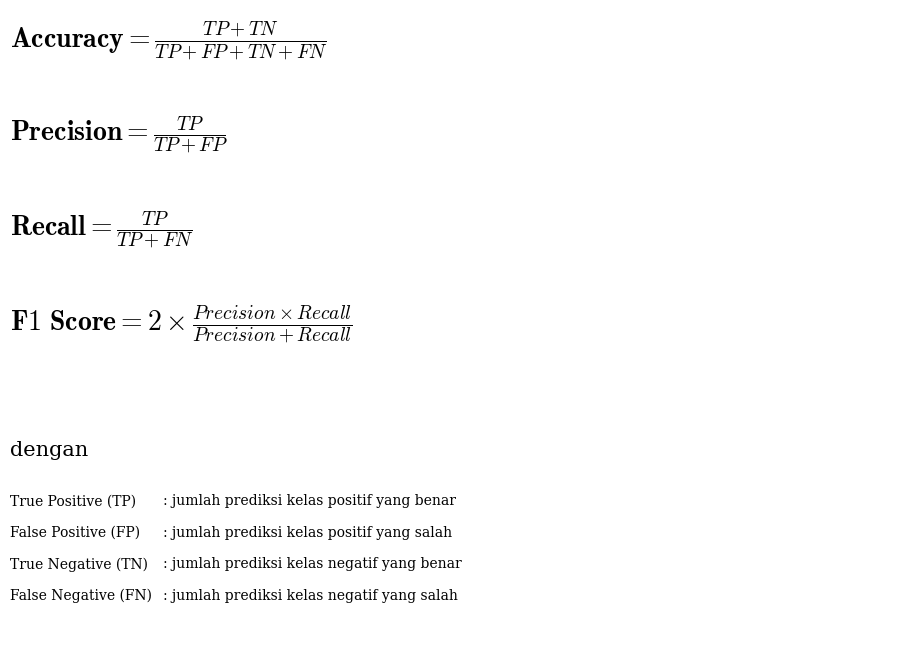

In [ ]:
"""
=============================================================================
CELL 12: CELL VISUALISASI: RUMUS METRIK EVALUASI & KETERANGAN
=============================================================================
Menghasilkan gambar rumus metrik evaluasi (Align Left)
lengkap dengan legenda/keterangan TP, FP, TN, FN yang sejajar rapi.
"""

import matplotlib.pyplot as plt

def plot_evaluation_formulas_with_legend():
    print("="*70)
    print("MEMBUAT GAMBAR RUMUS METRIK EVALUASI & KETERANGAN")
    print("="*70)

    # Pengaturan font akademis (Serif / Times New Roman style)
    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams['font.family'] = 'serif'

    # Buat kanvas, diperbesar secara vertikal (figsize 10x7)
    fig, ax = plt.subplots(figsize=(10, 7))
    fig.patch.set_facecolor('white')
    ax.axis('off')

    # 1. Bagian Rumus Utama
    formulas = [
        r"$\mathbf{Accuracy} = \frac{TP + TN}{TP + FP + TN + FN}$",
        r"$\mathbf{Precision} = \frac{TP}{TP + FP}$",
        r"$\mathbf{Recall} = \frac{TP}{TP + FN}$",
        r"$\mathbf{F1\ Score} = 2 \times \frac{Precision \times Recall}{Precision + Recall}$"
    ]

    y_start = 0.95
    y_step = 0.15

    # Cetak Rumus
    for i, formula in enumerate(formulas):
        ax.text(0.0, y_start - (i * y_step), formula,
                fontsize=20, ha='left', va='center')

    # 2. Bagian Keterangan (Legenda)
    # Tentukan titik mula Y untuk keterangan berdasarkan akhir rumus
    legend_y_start = y_start - (len(formulas) * y_step) - 0.05

    # Cetak kata "dengan"
    ax.text(0.0, legend_y_start, "dengan", fontsize=15, ha='left', va='center')

    # Data Legenda
    legends = [
        ("True Positive (TP)", ": jumlah prediksi kelas positif yang benar"),
        ("False Positive (FP)", ": jumlah prediksi kelas positif yang salah"),
        ("True Negative (TN)", ": jumlah prediksi kelas negatif yang benar"),
        ("False Negative (FN)", ": jumlah prediksi kelas negatif yang salah")
    ]

    leg_y = legend_y_start - 0.08 # Turun sedikit dari kata "dengan"
    leg_step = 0.05               # Jarak antar baris keterangan

    # Cetak Keterangan dengan titik dua yang sejajar
    for term, desc in legends:
        # Kolom Kiri: Nama Istilah (Dimulai di X=0.05 agak menjorok ke dalam)
        ax.text(0.00, leg_y, term, fontsize=10, ha='left', va='center')

        # Kolom Kanan: Titik Dua dan Deskripsi (Dimulai di X=0.30 agar titik dua rata vertikal)
        ax.text(0.17, leg_y, desc, fontsize=10, ha='left', va='center')

        leg_y -= leg_step # Turun ke baris selanjutnya

    # Sesuaikan margin agar seluruh konten muat
    plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)

    print("Gambar rumus & keterangan berhasil dibuat.")
    plt.show()

# --- EKSEKUSI ---
plot_evaluation_formulas_with_legend()